In [504]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [505]:
def split_data(df, features, targets, train_split: int=60, val_split=20, test_split=20):
    assert train_split + val_split + test_split == 100

    df = df.copy()
    
    n = df.shape[0]
    n_val = (int)(n * (val_split / 100))
    n_test = (int)(n * (test_split / 100))
    n_train = n - n_val - n_test
    
    indexes = np.arange(n)
    np.random.shuffle(indexes)

    df_train = df.iloc[indexes[: n_train]]
    df_val = df.iloc[indexes[n_train : n_train + n_val]]
    df_test = df.iloc[indexes[n_train + n_val : ]]

    
    
    y_train = df_train[targets]
    y_val = df_val[targets]
    y_test = df_test[targets]

    for t in targets:
        del df_train[t]
        del df_val[t]
        del df_test[t]

    X_train = df_train[features]
    X_val = df_val[features]
    X_test = df_test[features]
    
    return X_train, X_val, X_test, y_train, y_val, y_test

In [506]:
def rmse(y, y_pred):
    error = y - y_pred
    
    se = error ** 2
    mse = se.mean()

    return np.sqrt(mse)

In [507]:
def train_linear_regression(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    reg_matrix = r * np.eye(XTX.shape[0])
    XTX = XTX + reg_matrix
    
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

In [508]:
def prepare_X(df, features):
    X = df[features]
    return X

In [509]:
df = pd.read_csv("student-mat.csv", sep=";")
df.head()
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [510]:
df.columns = df.columns.str.lower()
df.head()

,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,...,famrel,freetime,goout,dalc,walc,health,absences,g1,g2,g3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [511]:
categorical_cols = list(df.select_dtypes("object").columns)
categorical_cols

['school',
 'sex',
 'address',
 'famsize',
 'pstatus',
 'mjob',
 'fjob',
 'reason',
 'guardian',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic']

In [512]:
for c in categorical_cols:
    items = df[c].unique()
    for item in items:
        df[f"{c}_{item}".lower()] = (df[c] == item).astype(int)
df.head()
df.dtypes[df.dtypes=="int64"]

age                  int64
medu                 int64
fedu                 int64
traveltime           int64
studytime            int64
failures             int64
famrel               int64
freetime             int64
goout                int64
dalc                 int64
walc                 int64
health               int64
absences             int64
g1                   int64
g2                   int64
g3                   int64
school_gp            int64
school_ms            int64
sex_f                int64
sex_m                int64
address_u            int64
address_r            int64
famsize_gt3          int64
famsize_le3          int64
pstatus_a            int64
pstatus_t            int64
mjob_at_home         int64
mjob_health          int64
mjob_other           int64
mjob_services        int64
mjob_teacher         int64
fjob_teacher         int64
fjob_other           int64
fjob_services        int64
fjob_health          int64
fjob_at_home         int64
reason_course        int64
r

In [513]:
features = list(df.dtypes[df.dtypes != "object"].index)
features.remove("g1")
features.remove("g2")
features.remove("g3")
features = ["studytime", "failures", "g1", "g2"]

In [514]:
targets = ["g3"]
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df, features, targets)

X_val.describe()

,studytime,failures,g1,g2
count,79.000000,79.000000,79.000000,79.000000
mean,1.974684,0.367089,11.303797,10.848101
std,0.816099,0.754087,3.631608,4.400142
min,1.000000,0.000000,5.000000,0.000000
25%,1.000000,0.000000,9.000000,9.000000
50%,2.000000,0.000000,11.000000,11.000000
75%,2.000000,0.000000,14.000000,14.000000
max,4.000000,3.000000,19.000000,19.000000


In [515]:
#y_train_g1 = y_train["g1"]
#y_train_g2 = y_train["g2"]
y_train_g3 = y_train["g3"]

In [516]:
#y_test_g1 = y_test["g1"]
#y_test_g2 = y_test["g2"]
y_test_g3 = y_test["g3"]

In [517]:
#y_val_g1 = y_val["g1"]
#y_val_g2 = y_val["g2"]
y_val_g3 = y_val["g3"]

In [518]:
r = 10
w0, w = train_linear_regression(X_train, y_train_g3, 17.2)
w0, w

(np.float64(-0.5134488402561267),
 array([-0.31025839, -0.36063181,  0.07484708,  1.01015001]))

In [519]:
y_pred_g3 = w0 + X_val.dot(w)

rmse(y_val_g3, y_pred_g3)

np.float64(1.3392670631552726)

<Axes: xlabel='g3', ylabel='Count'>

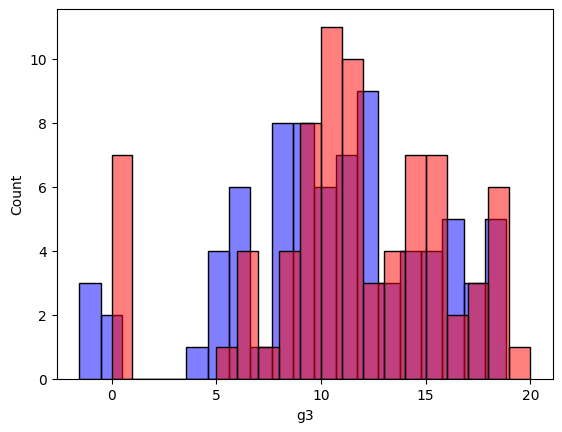

In [520]:
sns.histplot(y_pred_g3, color="blue", bins=20, alpha=0.5)
sns.histplot(y_val_g3, color="red", bins=20, alpha=0.5)

In [529]:
r_values = [10000, 1000, 100, 10, 1]


errors = []
min_error = 100000
min_r = None
for r in r_values:
    w0, w = train_linear_regression(X_train, y_train_g3, r)
    
    y_pred_g3 = w0 + X_val.dot(w)
    
    error = rmse(y_val_g3, y_pred_g3)

    if error < min_error:
        min_error = error
        min_r = r
    errors.append(error)

f"minimum error: {(float)(min_error)} from r={min_r}"


'minimum error: 1.325962164688501 from r=100'

<Axes: >

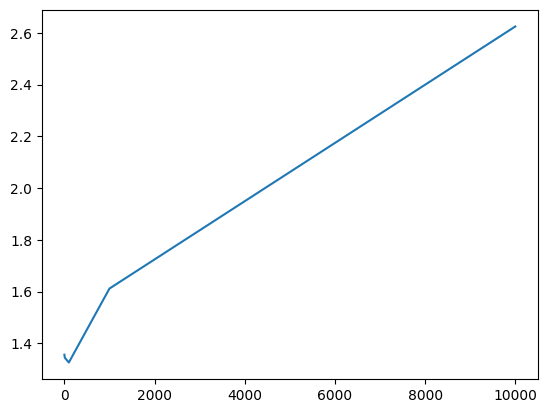

In [530]:
sns.lineplot(x=r_values, y=errors)

<Axes: xlabel='g3', ylabel='Count'>

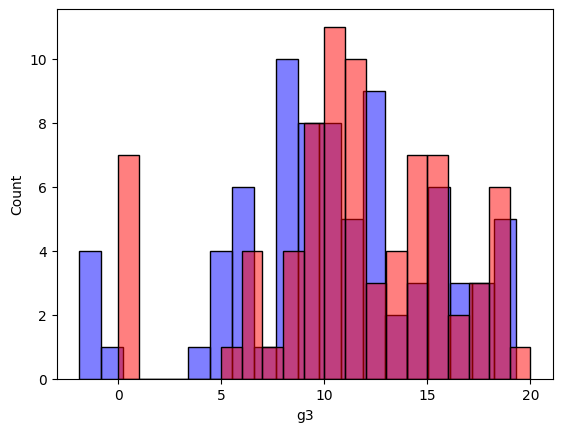

In [523]:
w0, w = train_linear_regression(X_train, y_train_g3, min_r)
y_pred_g3 = w0 + X_val.dot(w)

sns.histplot(y_pred_g3, color="blue", bins=20, alpha=0.5)
sns.histplot(y_val_g3, color="red", bins=20, alpha=0.5)